## **1. Mô tả dữ liệu**

Bộ dữ liệu được **USDA (Bộ Nông nghiệp Hoa Kỳ) cung cấp** mô tả về cơ sở dữ liệu thành phần dinh dưỡng thực phẩm

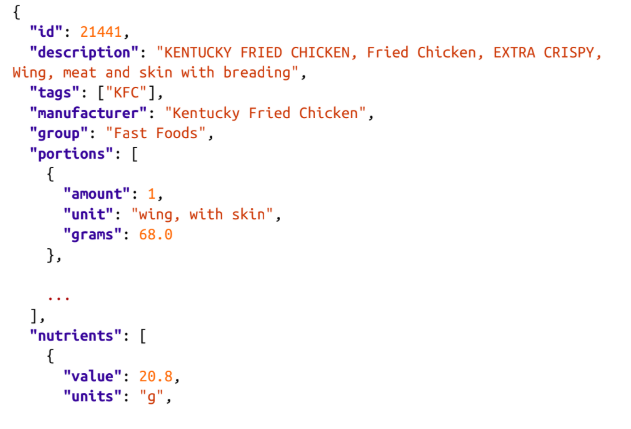)

### Ý nghĩa các trường trong dataset

| Trường            | Ý nghĩa                                               | Ví dụ                                |
|--------------------|--------------------------------------------------------|----------------------------------------|
| `description`      | Tên thực phẩm                                         | `Cheddar cheese`                       |
| `group`            | Nhóm thực phẩm                                       | `Dairy and Egg Products`               |
| `id`               | Mã định danh thực phẩm                               | `1001`                                 |
| `manufacturer`     | Nhà sản xuất (có thể là “Generic” nếu chung chung)   | `Generic`                              |
| `nutrients`        | Danh sách các chất dinh dưỡng                         | *(chi tiết bên dưới)*                  |

---

### Trường `nutrients` (dạng danh sách lồng)

| Trường con       | Ý nghĩa                          | Ví dụ                  |
|-------------------|-----------------------------------|-------------------------|
| `description`     | Tên chất dinh dưỡng              | `Protein`, `Calcium`    |
| `group`           | Nhóm chất                        | `Minerals`, `Energy`    |
| `unit`            | Đơn vị đo                        | `g`, `mg`, `kcal`       |
| `value`           | Giá trị dinh dưỡng trên 100g     | `24.9`, `403`           |

## **2. Tìm hiểu dữ liệu**

#### **2.1 Khai báo thư viện**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

#### **2.2 Đọc dữ liệu và xử lý dạng data dạng json**

In [3]:
db = json.load(open("database.json"))
len(db)

6636

**Nhận xét:**
- Mỗi phần tử trong biến db là 1 dictionary mô tả 1 loại thực phẩm.

- Bên trong đó có trường "nutrients" là một list chứa nhiều dictionary nhỏ — mỗi dictionary nhỏ mô tả 1 chất dinh dưỡng.

In [4]:
db[0].keys()

dict_keys(['id', 'description', 'tags', 'manufacturer', 'group', 'portions', 'nutrients'])

In [5]:
db[0]["nutrients"][0]

{'value': 25.18,
 'units': 'g',
 'description': 'Protein',
 'group': 'Composition'}

## **3. Tiền xử lý bảng chất dinh dưỡng**

In [6]:
nutrients = pd.DataFrame(db[0]["nutrients"])

In [7]:
nutrients.head(7)

,value,units,description,group
0,25.18,g,Protein,Composition
1,29.20,g,Total lipid (fat),Composition
2,3.06,g,"Carbohydrate, by difference",Composition
3,3.28,g,Ash,Other
4,376.00,kcal,Energy,Energy
5,39.28,g,Water,Composition
6,1573.00,kJ,Energy,Energy


**Trích xuất thông tin chung của thực phẩm**

In [9]:
info_keys = ["description", "group", "id", "manufacturer"]
info = pd.DataFrame(db, columns=info_keys)
info.head()

,description,group,id,manufacturer
0,"Cheese, caraway",Dairy and Egg Products,1008,
1,"Cheese, cheddar",Dairy and Egg Products,1009,
2,"Cheese, edam",Dairy and Egg Products,1018,
3,"Cheese, feta",Dairy and Egg Products,1019,
4,"Cheese, mozzarella, part skim milk",Dairy and Egg Products,1028,


**Kiểm tra dữ liệu**

In [10]:
info.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   description   6636 non-null   object
 1   group         6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


**Nhận xét**
- Manufacturer chỉ có 5195 giá trị → còn lại là NaN (thiếu)

#### **2.3 Thống kê tần suất xuất hiện trong từng nhóm sản phẩm**

In [11]:
pd.value_counts(info["group"])[:10]

C:\Users\sonvuuu\AppData\Local\Temp\ipykernel_21708\3634668934.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(info["group"])[:10]


group
Vegetables and Vegetable Products    812
Beef Products                        618
Baked Products                       496
Breakfast Cereals                    403
Legumes and Legume Products          365
Fast Foods                           365
Lamb, Veal, and Game Products        345
Sweets                               341
Fruits and Fruit Juices              328
Pork Products                        328
Name: count, dtype: int64

#### **2.4 Chuẩn hóa dữ liệu dinh dưỡng từ dạng JSON lồng nhau thành một bảng lớn**

In [17]:
nutrients = []
for rec in db:
    fnuts = pd.DataFrame(rec["nutrients"])
    fnuts["id"] = rec["id"]
    nutrients.append(fnuts)
nutrients = pd.concat(nutrients, ignore_index=True)
nutrients

,value,units,description,group,id
0,25.180,g,Protein,Composition,1008
1,29.200,g,Total lipid (fat),Composition,1008
2,3.060,g,"Carbohydrate, by difference",Composition,1008
3,3.280,g,Ash,Other,1008
4,376.000,kcal,Energy,Energy,1008
...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546
389351,0.000,mg,Cholesterol,Other,43546
389352,0.072,g,"Fatty acids, total saturated",Other,43546
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546


**Kiểm tra trùng**

In [14]:
nutrients.duplicated().sum()

np.int64(14179)

In [15]:
nutrients = nutrients.drop_duplicates()

**Đổi tên cho rõ**

In [16]:
col_mapping = {"description" : "food", "group" : "fgroup"}
info = info.rename(columns=col_mapping, copy=False)
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   food          6636 non-null   object
 1   fgroup        6636 non-null   object
 2   id            6636 non-null   int64 
 3   manufacturer  5195 non-null   object
dtypes: int64(1), object(3)
memory usage: 207.5+ KB


## **4. Làm sạch & chuẩn hóa dữ liệu**

In [42]:
col_mapping = {"description" : "nutrient", "group" : "nutgroup"}
nutrients = nutrients.rename(columns=col_mapping, copy=False)
nutrients

,value,units,nutrient,nutgroup,id
0,25.180,g,Protein,Composition,1008
1,29.200,g,Total lipid (fat),Composition,1008
2,3.060,g,"Carbohydrate, by difference",Composition,1008
3,3.280,g,Ash,Other,1008
4,376.000,kcal,Energy,Energy,1008
...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546
389351,0.000,mg,Cholesterol,Other,43546
389352,0.072,g,"Fatty acids, total saturated",Other,43546
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546


**Merge inf với nutrients**

In [18]:
ndata = pd.merge(nutrients, info, on="id")

In [19]:
ndata

,value,units,description,group,id,food,fgroup,manufacturer
0,25.180,g,Protein,Composition,1008,"Cheese, caraway",Dairy and Egg Products,
1,29.200,g,Total lipid (fat),Composition,1008,"Cheese, caraway",Dairy and Egg Products,
2,3.060,g,"Carbohydrate, by difference",Composition,1008,"Cheese, caraway",Dairy and Egg Products,
3,3.280,g,Ash,Other,1008,"Cheese, caraway",Dairy and Egg Products,
4,376.000,kcal,Energy,Energy,1008,"Cheese, caraway",Dairy and Egg Products,
...,...,...,...,...,...,...,...,...
389350,0.000,mcg,"Vitamin B-12, added",Vitamins,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
389351,0.000,mg,Cholesterol,Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
389352,0.072,g,"Fatty acids, total saturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None
389353,0.028,g,"Fatty acids, total monounsaturated",Other,43546,"Babyfood, banana no tapioca, strained",Baby Foods,None


In [31]:
ndata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375176 entries, 0 to 375175
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   value         375176 non-null  float64
 1   units         375176 non-null  object 
 2   nutrient      375176 non-null  object 
 3   nutgroup      375176 non-null  object 
 4   id            375176 non-null  int64  
 5   food          375176 non-null  object 
 6   fgroup        375176 non-null  object 
 7   manufacturer  293054 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 22.9+ MB


## **5. Phân tích & trực quan hóa (Biểu đồ hàm lượng kẽm (Zn) trung vị theo nhóm thực phẩm)**

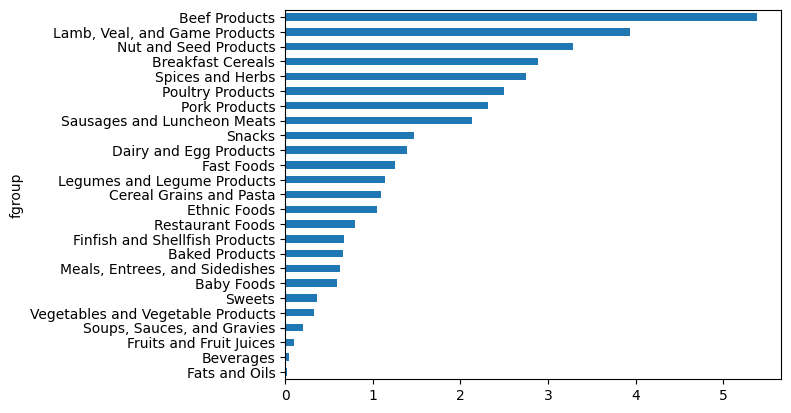

In [35]:
result = ndata.groupby(["nutrient", "fgroup"])["value"].median()
result["Zinc, Zn"].sort_values().plot(kind="barh");

In [43]:
info[info["group"] == "Beef Products"].head(10)

,description,group,id,manufacturer
2367,"Beef, grass-fed, strip steaks, lean only, raw",Beef Products,13000,None
2368,"Beef, carcass, separable lean and fat, choice,...",Beef Products,13001,
2369,"Beef, carcass, separable lean and fat, select,...",Beef Products,13002,
2370,"Beef, retail cuts, separable fat, raw",Beef Products,13019,
2371,"Beef, retail cuts, separable fat, cooked",Beef Products,13020,
2372,"Beef, brisket, whole, separable lean only, all...",Beef Products,13023,
2373,"Beef, grass-fed, ground, raw",Beef Products,13047,None
2374,"Beef, brisket, flat half, separable lean and f...",Beef Products,13055,
2375,"Beef, flank, steak, separable lean and fat, tr...",Beef Products,13065,
2376,"Beef, flank, steak, separable lean and fat, tr...",Beef Products,13066,


**Nhận xét:**
- Thịt bò chứa nhiều kẽm nhất

In [44]:
by_nutrient = ndata.groupby(["nutgroup", "nutrient"])
def get_maximum(x):
    return x.loc[x.value.idxmax()]

max_foods = by_nutrient.apply(get_maximum)[["value", "food"]]
# make the food a little smaller
max_foods["food"] = max_foods["food"].str[:50]

C:\Users\sonvuuu\AppData\Local\Temp\ipykernel_14692\2603253626.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  max_foods = by_nutrient.apply(get_maximum)[["value", "food"]]


In [45]:
max_foods.loc["Amino Acids"]["food"]

nutrient
Alanine                           Gelatins, dry powder, unsweetened
Arginine                               Seeds, sesame flour, low-fat
Aspartic acid                                   Soy protein isolate
Cystine                Seeds, cottonseed flour, low fat (glandless)
Glutamic acid                                   Soy protein isolate
Glycine                           Gelatins, dry powder, unsweetened
Histidine                Whale, beluga, meat, dried (Alaska Native)
Hydroxyproline    KENTUCKY FRIED CHICKEN, Fried Chicken, ORIGINA...
Isoleucine        Soy protein isolate, PROTEIN TECHNOLOGIES INTE...
Leucine           Soy protein isolate, PROTEIN TECHNOLOGIES INTE...
Lysine            Seal, bearded (Oogruk), meat, dried (Alaska Na...
Methionine                    Fish, cod, Atlantic, dried and salted
Phenylalanine     Soy protein isolate, PROTEIN TECHNOLOGIES INTE...
Proline                           Gelatins, dry powder, unsweetened
Serine            Soy protein isolate, 